In [1]:
# Text classification using RNN 

In [2]:
# Monthly Milk Production Forecasting 
# Using RNN, LSTM, and GRU Deep Learning Models

In [3]:
# ✅ Assignment Tasks

In [4]:
#  1.Exploratory Data Analysis (EDA)
#      Visualize trends, seasonality, and anomalies in the milk production data
#      Check for any missing values or outliers.
#      Normalize or scale the data for neural network models.

In [5]:
# Visualize trends, seasonality, and anomalies in the milk production data

In [6]:
import pandas as pd
df= pd.read_csv("monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [7]:
df.shape

(168, 2)

In [8]:
pip install pandas numpy matplotlib seaborn statsmodels scipy

In [9]:
import pandas as pd
df= pd.read_csv("monthly_milk_production.csv",parse_dates=["Date"],index_col='Date')
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


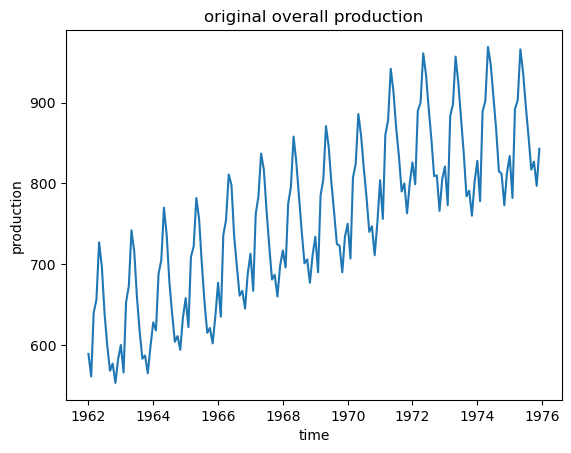

In [10]:
# plotting original data
import matplotlib.pyplot as plt
plt.title("original overall production")  # actually it is increasing
plt.plot(df['Production'])
plt.xlabel("time")
plt.ylabel('production')
plt.show()

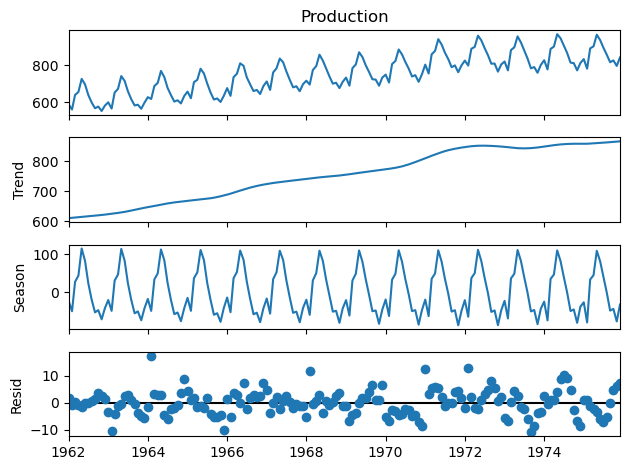

In [11]:
# visualization of production,trend,seasonality,noise(residuals)
from statsmodels.tsa.seasonal import STL
ts= df['Production']
stl = STL(ts,period=12)
result = stl.fit()
result.plot()
plt.show()

In [12]:
# extracting the trend ,seasonality and residuals from the above result
trend = result.trend
seasonal = result.seasonal
residual = result.resid

In [13]:
from scipy import stats
import numpy as np
# clean residuals--- cleaning residuals after decomposition
resid_clean= residual.dropna()
# compute z_scores -- how many standard deviation a value far away from the mean
z_scores = stats.zscore(resid_clean)
threshold = 3
anomalies= resid_clean[z_scores>threshold]
anomalies

Date
1964-02-01    17.39099
Name: resid, dtype: float64

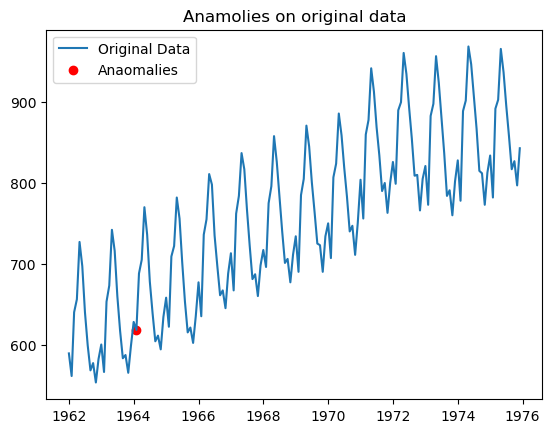

In [14]:
# plotting anomalies on Original series
plt.plot(ts,label ="Original Data")
plt.scatter(anomalies.index,ts.loc[anomalies.index],color='red',label = 'Anaomalies')
plt.title("Anamolies on original data")
plt.legend()
plt.show()


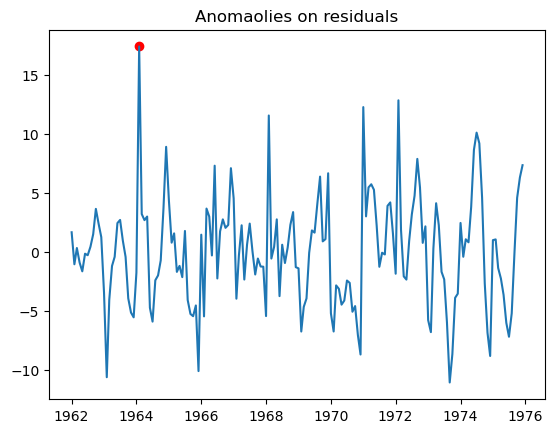

In [15]:
# plotting anomalies on residuals
plt.plot(residual,label='Residuals')
plt.scatter(anomalies.index,residual.loc[anomalies.index],color='red',label='Anomalies')
plt.title('Anomaolies on residuals')
plt.show()

In [16]:
# Check for any missing values or outliers.
df.isnull().sum()  # there are no missing values

Production    0
dtype: int64

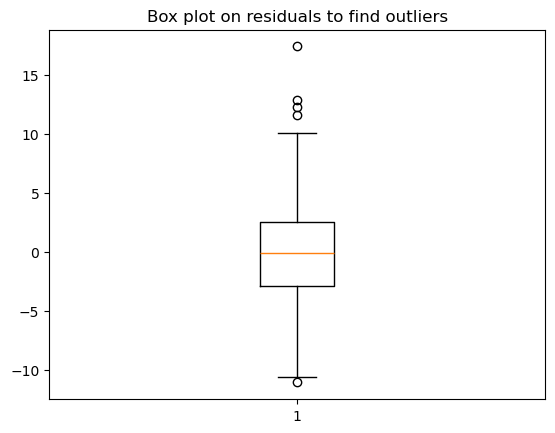

In [17]:
# Box plot on residuals to find outliers
plt.boxplot(resid_clean)
plt.title("Box plot on residuals to find outliers")  # There are outliers 
plt.show()

In [18]:
import numpy as np
q1= np.round(np.percentile(resid_clean,25),2)
q2= np.round(np.percentile(resid_clean,50),2)
q3= np.round(np.percentile(resid_clean,75),2)
iqr=q3-q1
uw= q3+(iqr*1.5)
lw= q1-(iqr*1.5)

In [19]:
len(resid_clean[resid_clean>uw])

4

In [20]:
len(resid_clean[resid_clean<lw])

1

In [21]:
resid_clean[resid_clean>uw]=uw
resid_clean[resid_clean<lw]=lw

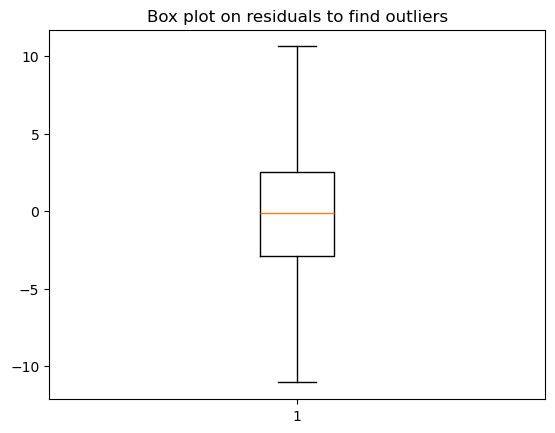

In [22]:
plt.boxplot(resid_clean)
plt.title("Box plot on residuals to find outliers")  # Now the outliers are removed 
plt.show()

In [23]:
# Normalize or scale the data for neural network models.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production']])
scaled_data

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231],
       [0.        ],
       [0.06971154],
       [0.11298077],
       [0.03125   ],
       [0.24038462],
       [0.28846154],
       [0.45432692],
       [0.39182692],
       [0.25721154],
       [0.15384615],
       [0.07211538],
       [0.08173077],
       [0.02884615],
       [0.10817308],
       [0.18028846],
       [0.15625   ],
       [0.32451923],
       [0.36538462],
       [0.52163462],
       [0.43990385],
       [0.30048077],
       [0.20673077],
       [0.12259615],
       [0.13942308],
       [0.09855769],
       [0.19471154],
       [0.25240385],
       [0.16586538],
       [0.375     ],
       [0.40625   ],
       [0.55048077],
       [0.48798077],
       [0.35817308],
       [0.24038462],
       [0.14903846],
       [0.16346154],
       [0.11778846],
       [0.197

In [24]:
# 2. Data Preparation for Deep Learning
# 	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
#	Split data into training, validation, and test sets.
#	Reshape data for model input dimensions.

In [25]:
# 	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.
# Create Time Window Function
def create_sequence(data,window_size):
    X = [] 
    Y = []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        Y.append(data[i+window_size])
    return np.array(X),np.array(Y)


window_size=12
X,Y= create_sequence(scaled_data,window_size)
print(f"X shape is {X.shape}")
print(f"Y shape is {Y.shape}")

X shape is (156, 12, 1)
Y shape is (156, 1)


In [26]:
# Split data into training, validation, and test sets
train_size= int(len(X)*0.8)
val_size = int(len(X) * 0.15)

X_train=X[:train_size] # Training
Y_train=Y[:train_size] 

X_val = X[train_size:train_size+val_size] # validation
Y_val = Y[train_size:train_size+val_size]

X_test= X[train_size:]# testing
Y_test= Y[train_size:]

In [27]:
# Reshape data for model input dimensions.
print(f"Training : {X_train}")
print(f"validation : {X_val}")
print(f"Testing : {X_test}")

Training : [[[0.08653846]
  [0.01923077]
  [0.20913462]
  ...
  [0.05769231]
  [0.        ]
  [0.06971154]]

 [[0.01923077]
  [0.20913462]
  [0.24759615]
  ...
  [0.        ]
  [0.06971154]
  [0.11298077]]

 [[0.20913462]
  [0.24759615]
  [0.41826923]
  ...
  [0.06971154]
  [0.11298077]
  [0.03125   ]]

 ...

 [[0.59134615]
  [0.81009615]
  [0.83413462]
  ...
  [0.51201923]
  [0.60576923]
  [0.64423077]]

 [[0.81009615]
  [0.83413462]
  [0.98076923]
  ...
  [0.60576923]
  [0.64423077]
  [0.52884615]]

 [[0.83413462]
  [0.98076923]
  [0.91826923]
  ...
  [0.64423077]
  [0.52884615]
  [0.79326923]]]
validation : [[[0.98076923]
  [0.91826923]
  [0.81971154]
  [0.72596154]
  [0.61538462]
  [0.61778846]
  [0.51201923]
  [0.60576923]
  [0.64423077]
  [0.52884615]
  [0.79326923]
  [0.82932692]]

 [[0.91826923]
  [0.81971154]
  [0.72596154]
  [0.61538462]
  [0.61778846]
  [0.51201923]
  [0.60576923]
  [0.64423077]
  [0.52884615]
  [0.79326923]
  [0.82932692]
  [0.97115385]]

 [[0.81971154]
  [

In [28]:
print(f"shape of trianing is {X_train.shape}") # correct shape for the model
print(f"shape of validation is {X_val.shape}")
print(f"shape of testing is {X_test.shape}")

shape of trianing is (124, 12, 1)
shape of validation is (23, 12, 1)
shape of testing is (32, 12, 1)


In [29]:
# 3.Model Building
# Build three separate models:
#	Basic RNN
#	LSTM
#	GRU
# Tune hyperparameters (e.g., window size, number of units, batch size, epochs).
# Use appropriate loss functions and optimizers.

In [30]:
# Basic RNN
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN,Dense
from tensorflow.keras.optimizers import Adam
model = Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(X_train.shape[1],X_train.shape[2]))) # simple RNN layer
model.add(Dense(1)) # dense layer

C:\Users\andeb\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(optimizer='adam',loss='mse') # compile the model
# fit the model
history = model.fit(X_train,Y_train,validation_data=(X_val,Y_val),epochs=50,batch_size=16)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.1343 - val_loss: 0.0377
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0430 - val_loss: 0.0168
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0140 - val_loss: 0.0322
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0082 - val_loss: 0.0074
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0036 - val_loss: 0.0056
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0030 - val_loss: 0.0043
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0023 - val_loss: 0.0034
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - val_loss: 0.0031
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - val_loss: 0.0031
E

In [32]:
# predicting the model
Y_pred = model.predict(X_test)
print("Predicted values:")
print(Y_pred[:5])

print("Actual values:")
print(Y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
Predicted values:
[[0.9223589 ]
 [0.8901537 ]
 [0.8241875 ]
 [0.74658823]
 [0.6352575 ]]
Actual values:
[[0.97115385]
 [0.89182692]
 [0.78846154]
 [0.68269231]
 [0.55528846]]


In [33]:
Y_pred.shape

(32, 1)

In [34]:
Y_test.shape

(32, 1)

In [35]:
# Tune hyperparameters (e.g., window size, number of units, batch size, epochs) for RNN model
from tensorflow.keras.models import Sequential # importing Sequential,SimpleRNN,Dense,Dropout,Adam
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# create a function
def create_rnn_model(rnn_units=50,dropout_rate=0.2,learning_rate=0.001,window_size=12):
    model=Sequential()
    model.add(SimpleRNN(units,activation='tanh',input_shape=(window_size,1)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    optimizer = Adam(learning_rate= learning_rate)
    model.compile(optimizer= optimizer,loss='mse')
    return model

# define hyperparameter options
window_size = [6,12] # timesteps
rnn_units= [32,50] # number of units
batch_sizes= [8,16]
epochs= [50, 100]
learning_rate = [0.001, 0.005]
dropout_rates = [0.1, 0.2]


In [ ]:
best_val_loss= float('inf')
best_params={}

# creating the X_train_raw,X_val_raw
X_train_raw = [X_train [0,0,0]]
for seq in X_train:
    X_train_raw.append(seq[-1,0])
X_train_raw = np.array(X_train_raw)
print("X_train_raw shape:", X_train_raw.shape)

X_val_raw = [X_val [0,0,0]]
for seq in X_val:
    X_val_raw.append(seq[-1,0])
X_val_raw = np.array(X_val_raw)
print("X_val_raw shape:", X_val_raw.shape)

# Function to create sequences for any window size
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

for window in window_size:
    X_train_seq, Y_train_seq = create_sequences(X_train_raw, window)
    X_val_seq, Y_val_seq = create_sequences(X_val_raw, window)
    
    for units in rnn_units:
        for batch in batch_sizes:
            for ep in epochs:
                for lr in learning_rate:
                    for dropout in dropout_rates:
                        print(f"Training: window={window}, units={units}, batch={batch}, epochs={ep}, lr={lr}, dropout={dropout}")
                        
                        model = create_rnn_model(rnn_units=units, window_size=window,
                                                 dropout_rate=dropout, learning_rate=lr)
                        history = model.fit(
                            X_train_seq, Y_train_seq,
                            validation_data=(X_val_seq, Y_val_seq),
                            epochs=ep,
                            batch_size=batch,
                            verbose=1
                        )
                         
                        val_loss = min(history.history['val_loss'])
                        if val_loss < best_val_loss:
                            best_val_loss = val_loss
                            best_params = {
                                'window_size': window,
                                'rnn_units': units,
                                'batch_size': batch,
                                'epochs': ep,
                                'learning_rate': lr,
                                'dropout_rate': dropout
                            }

                            print("⭐ New Best Model Found!")
                            print("Validation Loss:", best_val_loss)
                            print("Parameters:", best_params)
                            print("--------------------------------------------------")

print("\n✅ FINAL BEST HYPERPARAMETERS")
print(best_params)
print("Best Validation Loss:", best_val_loss)

X_train_raw shape: (125,)
X_val_raw shape: (24,)
Training: window=6, units=32, batch=8, epochs=50, lr=0.001, dropout=0.1
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.1438 - val_loss: 0.0445
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0683 - val_loss: 0.0445
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0399 - val_loss: 0.0228
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0325 - val_loss: 0.0241
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0310 - val_loss: 0.0256
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0252 - val_loss: 0.0197
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0250 - val_loss: 0.0169
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0201 - val_loss: 0.0273
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0218 - val_loss: 0.0141
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0192 - val_loss: 0.0148
Epoch 11/50
15/15 ━━━━━━━━━━

In [ ]:
# Best parameters are window_size = 12,rnn_units=50,batch_size=8,epochs=50,learning_rate=0.001,dropout_rate=0.2
# best validation loss is 0.000803345

In [39]:
#	LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
# create sequence
import numpy as np
def create_sequences(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
         X.append(data[i:i+seq_length])
         Y.append(data[i+seq_length])     

    X = np.array(X)
    Y = np.array(Y)

    return X, Y
sequence_length = 6  
X, Y = create_sequences(scaled_data, sequence_length)
print(X.shape)
print(Y.shape)  

# Train-Test Split
split = int(0.8 * len(X))
X_train,X_test1= X[:split],X[split:]
Y_train,Y_test1= Y[:split],Y[split:]

# building the model
model1= Sequential()
model1.add(LSTM(64,activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
model1.add(Dense(1))
model1.compile(optimizer='adam',loss='mse')

# training the model
history = model1.fit(X_train, Y_train, epochs=50, batch_size=16, validation_data=(X_test1, Y_test1))

(162, 6, 1)
(162, 1)
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.2042 - val_loss: 0.4092
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1512 - val_loss: 0.2958
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1005 - val_loss: 0.1742
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0534 - val_loss: 0.0586
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0406 - val_loss: 0.0334
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0374 - val_loss: 0.0427
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0319 - val_loss: 0.0536
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0319 - val_loss: 0.0416
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0311 - val_loss: 0.0403
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307 - val_loss: 0.0475
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0313 - val_loss: 0.0472
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0303

In [40]:
# predicting the model
Y_pred1 = model1.predict(X_test1)
print("Predicted values:")
print(Y_pred1[:5])

print("Actual values:")
print(Y_test1[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Predicted values:
[[0.6431156 ]
 [0.7467017 ]
 [0.8413886 ]
 [0.84138083]
 [0.7883642 ]]
Actual values:
[[0.82932692]
 [0.97115385]
 [0.89182692]
 [0.78846154]
 [0.68269231]]


In [41]:
# Tune hyperparameters (e.g., window size, number of units, batch size, epochs) for LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Function to Create LSTM Model
def create_lstm_function(units=50,dropout_rate=0.2,learning_rate=0.001,window_size=6):
    model1= Sequential()
    model1.add(LSTM(units,activation='relu',input_shape=(window_size,1)))
    model1.add(Dropout(dropout_rate))
    model1.add(Dense(1))
    optimizer= Adam(learning_rate= learning_rate)
    model1.compile(optimizer= optimizer, loss='mse')
    return model1 

# Define parameters
learning_rate =[0.001,0.005]
dropout_rate= [0.1,0.2]
epochs=[20,30]
lstm_units=[50,60]
window_size=[6,12]
batch_size=[8,16]   
    
best_test_loss= float('inf')
best_params ={}

# creating the X_train_raw,X_test_raw
X_train_raw = X_train[0,0,0].reshape(1)  # make it 1D array
for seq in X_train:
    X_train_raw = np.append(X_train_raw, seq[-1,0])
print("X_train_raw shape:", X_train_raw.shape)

X_test_raw = X_test[0,0,0].reshape(1)  # make it 1D array
for seq in X_test:
    X_test_raw = np.append(X_test_raw, seq[-1,0])
print("X_test_raw shape:", X_test_raw.shape)

# Function to create sequences for any window size
def create_sequences(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        Y.append(data[i+window_size])
    X = np.array(X)
    X= X.reshape((X.shape[0],X.shape[1],1))  # reshape for LSTM
    Y= np.array(Y)
    return X,Y
    
# hyperparameter tunning loop
for window in window_size:
    X_train_seq,Y_train_seq= create_sequences(X_train_raw,window)
    X_test_seq,Y_test_seq= create_sequences(X_test_raw,window)
    for units in lstm_units:
        for batch in batch_size:
            for ep in epochs:
                for lr in learning_rate:
                    for dropout in dropout_rate:
                        print(f"Training: window={window},units={units},batch={batch},epochs={ep},lr={lr},dropout={dropout}")
                        model1 = create_lstm_function(units=units,dropout_rate=dropout,learning_rate=lr,window_size=window)
                        history = model1.fit(X_train_seq, Y_train_seq, epochs=ep, batch_size=batch, validation_data=(X_test_seq, Y_test_seq),verbose=1)
                        val_loss= min(history.history['val_loss'])
                        if val_loss < best_test_loss:
                            best_test_loss = val_loss
                            best_params={
                                "learning_rate" : lr,
                                "dropout_rate" : dropout,
                                "epochs" : ep,
                                "lstm_units" : units,
                                "window_size" : window,
                                "batch_size" : batch
                            }
                            print("Validation Loss:" , best_test_loss)
                            print("Best Parameters:",best_params)

X_train_raw shape: (130,)
X_test_raw shape: (33,)
Training: window=6,units=50,batch=8,epochs=20,lr=0.001,dropout=0.1
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1538 - val_loss: 0.1996
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0602 - val_loss: 0.0397
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0331 - val_loss: 0.0316
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293 - val_loss: 0.0392
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0274 - val_loss: 0.0331
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0322 - val_loss: 0.0318
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0286 - val_loss: 0.0349
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0279 - val_loss: 0.0330
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0266 - val_loss: 0.0309
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0280 - val_loss: 0.0317
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s

In [43]:
print(best_params)
print("Best Validation Loss:", best_test_loss)
# {'learning_rate': 0.005, 'dropout_rate': 0.1, 'epochs': 30, 'lstm_units': 60, 'window_size': 12, 'batch_size': 8}
# Best Validation Loss: 0.0029376009479165077

{'learning_rate': 0.005, 'dropout_rate': 0.1, 'epochs': 30, 'lstm_units': 50, 'window_size': 12, 'batch_size': 8}
Best Validation Loss: 0.002277517458423972


In [44]:
# GRU (Gated Recurrent unit) model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU,Dense,Dropout
# create sequence
import numpy as np
def create_sequences(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
         X.append(data[i:i+seq_length])
         Y.append(data[i+seq_length])     

    X = np.array(X)
    Y = np.array(Y)

    return X, Y
sequence_length = 6  
X, Y = create_sequences(scaled_data, sequence_length)
print(X.shape)
print(Y.shape)  

# Train-Test Split
split = int(0.8 * len(X))
X_train,X_test2= X[:split],X[split:]
Y_train,Y_test2= Y[:split],Y[split:]
# building the model
model2= Sequential()
model2.add(GRU(64,activation='relu',input_shape=(X_train.shape[1],X_train.shape[2])))
model2.add(Dense(1))
model2.compile(optimizer='adam',loss='mse')

# training the model
history = model2.fit(X_train, Y_train, epochs=50, batch_size=16, validation_data=(X_test2, Y_test2))

# predicting the model
Y_pred2 = model2.predict(X_test2)
print("Predicted values:")
print(Y_pred2[:5])

print("Actual values:")
print(Y_test2[:5])

(162, 6, 1)
(162, 1)
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.1867 - val_loss: 0.3304
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1085 - val_loss: 0.1792
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0544 - val_loss: 0.0721
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0289 - val_loss: 0.0324
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0276 - val_loss: 0.0343
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0258 - val_loss: 0.0346
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0248 - val_loss: 0.0409
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0244 - val_loss: 0.0403
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0237 - val_loss: 0.0311
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0222 - val_loss: 0.0262
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0215 - val_loss: 0.0278
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0211

In [45]:
# Tune hyperparameters (e.g., window size, number of units, batch size, epochs) for GRU model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU,Dense,Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Function to Create LSTM Model
def create_gru_function(units=50,dropout_rate=0.2,learning_rate=0.001,window_size=6):
    model2= Sequential()
    model2.add(GRU(units,activation='relu',input_shape=(window_size,1)))
    model2.add(Dropout(dropout_rate))
    model2.add(Dense(1))
    optimizer= Adam(learning_rate= learning_rate)
    model2.compile(optimizer= optimizer, loss='mse')
    return model2 
    
# Define parameters
learning_rate =[0.001,0.005]
dropout_rate= [0.1,0.2]
epochs=[20,30]
lstm_units=[50,60]
window_size=[6,12]
batch_size=[8,16]   
    
best_test_loss= float('inf')
best_params ={}

# creating the X_train_raw,X_test_raw
X_train_raw = X_train[0,0,0].reshape(1)  # make it 1D array
for seq in X_train:
    X_train_raw = np.append(X_train_raw, seq[-1,0])
print("X_train_raw shape:", X_train_raw.shape)

X_test_raw = X_test[0,0,0].reshape(1)  # make it 1D array
for seq in X_test:
    X_test_raw = np.append(X_test_raw, seq[-1,0])
print("X_test_raw shape:", X_test_raw.shape)

# Function to create sequences for any window size
def create_sequences(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        Y.append(data[i+window_size])
    X = np.array(X)
    X= X.reshape((X.shape[0],X.shape[1],1))  
    Y= np.array(Y)
    return X,Y

# hyperparameter tunning loop
for window in window_size:
    X_train_seq,Y_train_seq= create_sequences(X_train_raw,window)
    X_test_seq,Y_test_seq= create_sequences(X_test_raw,window)
    for units in lstm_units:
        for batch in batch_size:
            for ep in epochs:
                for lr in learning_rate:
                    for dropout in dropout_rate:
                        print(f"Training: window={window},units={units},batch={batch},epochs={ep},lr={lr},dropout={dropout}")
                        model2 = create_lstm_function(units=units,dropout_rate=dropout,learning_rate=lr,window_size=window)
                        history = model2.fit(X_train_seq, Y_train_seq, epochs=ep, batch_size=batch, validation_data=(X_test_seq, Y_test_seq),verbose=1)
                        val_loss= min(history.history['val_loss'])
                        if val_loss < best_test_loss:
                            best_test_loss = val_loss
                            best_params={
                                "learning_rate" : lr,
                                "dropout_rate" : dropout,
                                "epochs" : ep,
                                "lstm_units" : units,
                                "window_size" : window,
                                "batch_size" : batch
                            }
                            print("Validation Loss:" , best_test_loss)
                            print("BestParameters :",best_params)
print(best_params)
print("Best Validation Loss:", best_test_loss)    

X_train_raw shape: (130,)
X_test_raw shape: (33,)
Training: window=6,units=50,batch=8,epochs=20,lr=0.001,dropout=0.1
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.2523 - val_loss: 0.4304
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1440 - val_loss: 0.2228
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0597 - val_loss: 0.0493
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0376 - val_loss: 0.0379
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0307 - val_loss: 0.0389
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0320 - val_loss: 0.0358
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0283 - val_loss: 0.0324
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0288 - val_loss: 0.0326
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0252 - val_loss: 0.0289
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0263 - val_loss: 0.0291
Epoch 11/20
16/16 ━━━━━━━━━━━━━━

In [ ]:
# BestParameters :{'learning_rate': 0.005, 'dropout_rate': 0.2, 'epochs': 30, 'lstm_units': 50, 'window_size': 12, 'batch_size': 8}
# Best Validation Loss: 0.001978963380679488

In [ ]:
# 4.Model Evaluation
# 	Plot predictions vs. actual values.
#	Calculate forecasting metrics: RMSE, MAE, MAPE.
#	Compare the performance of RNN, LSTM, and GRU.

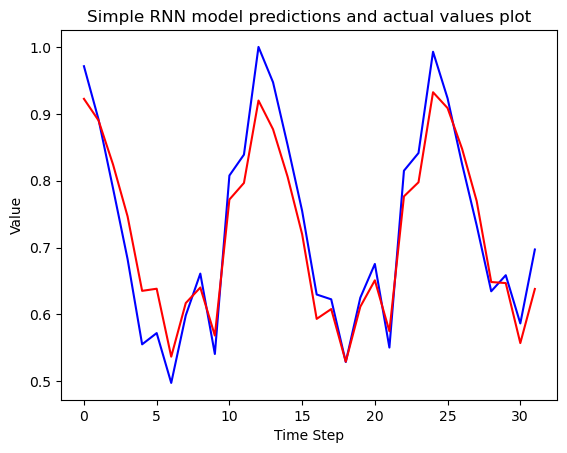

In [46]:
# 	Plot predictions vs. actual values.
# 	Plot predictions vs. actual values of Simple RNN model
import matplotlib.pyplot as plt
plt.plot(Y_test,label="Actual values",color='blue')
plt.plot(Y_pred,label="Predicted vaues",color='red')
plt.title("Simple RNN model predictions and actual values plot")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()

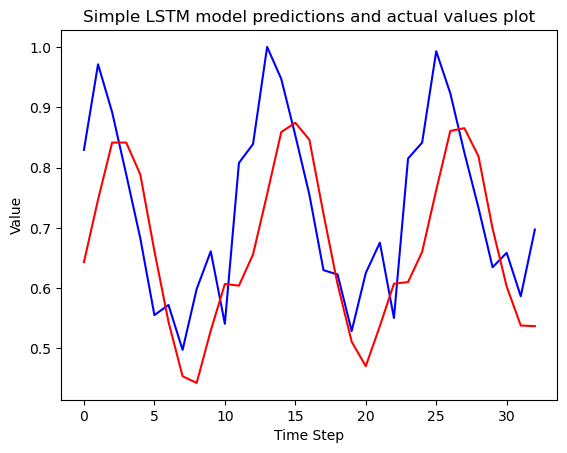

In [47]:
# 	Plot predictions vs. actual values of LSTM model
import matplotlib.pyplot as plt
plt.plot(Y_test1,label="Actual values",color='blue')
plt.plot(Y_pred1,label="Predicted vaues",color='red')
plt.title("Simple LSTM model predictions and actual values plot")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()

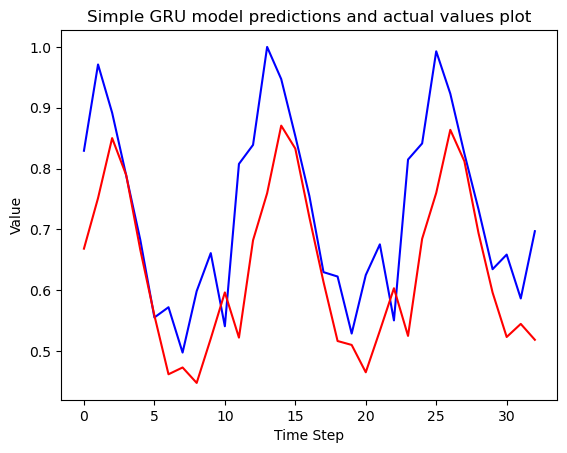

In [48]:
# 	Plot predictions vs. actual values of GRU model
import matplotlib.pyplot as plt
plt.plot(Y_test2,label="Actual values",color='blue')
plt.plot(Y_pred2,label="Predicted vaues",color='red')
plt.title("Simple GRU model predictions and actual values plot")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()

In [49]:
#Calculate forecasting metrics: RMSE, MAE, MAPE.
#	Calculate forecasting metrics: RMSE, MAE, MAPE for Simple RNN
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
Y_pred_inv = scaler.inverse_transform(Y_pred.reshape(-1,1)).flatten()
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1,1)).flatten()
Y_test_seq = Y_test_inv[-len(Y_pred_inv):] # the order of two sets Y_test and Y_pred is not same ,reduced one from that to make equal
rmse=root_mean_squared_error(Y_test_seq,Y_pred_inv) 
mae= np.sqrt(mean_absolute_error(Y_test_seq,Y_pred_inv))
mape=np.mean(np.abs((Y_test_seq-Y_pred_inv)/Y_test_seq))*100
print(f"RMSE for Simple RNN model is {np.round(rmse,2)}")
print(f"MAE for Simple RNN model is {np.round(mae,2)}")
print(f"MAPE for Simple RNN model is {np.round(mape,2)}")

RMSE for Simple RNN model is 17.44
MAE for Simple RNN model is 3.88
MAPE for Simple RNN model is 1.75


In [50]:
#	Calculate forecasting metrics: RMSE, MAE, MAPE for LSTM
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
Y_test1_seq = Y_test1[-len(Y_pred1):] # the order of two sets Y_test and Y_pred is not same ,reduced one from that to make equal
rmse=root_mean_squared_error(Y_test1_seq,Y_pred1) 
mae= np.sqrt(mean_absolute_error(Y_test1_seq,Y_pred1))
mape=np.mean(np.abs((Y_test1_seq-Y_pred1)/Y_test1_seq))*100
print(f"RMSE for LSTM model is {np.round(rmse,2)}")
print(f"MAE for LSTM model is {np.round(mae,2)}")
print(f"MAPE for LSTM model is {np.round(mape,2)}")

RMSE for LSTM model is 0.13
MAE for LSTM model is 0.33
MAPE for LSTM model is 14.51


In [51]:
#	Calculate forecasting metrics: RMSE, MAE, MAPE for GRU
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
Y_test2_seq = Y_test2[-len(Y_pred2):] # the order of two sets Y_test and Y_pred is not same ,reduced one from that to make equal
rmse=root_mean_squared_error(Y_test2_seq,Y_pred2) 
mae= np.sqrt(mean_absolute_error(Y_test2_seq,Y_pred2))
mape=np.mean(np.abs((Y_test2_seq-Y_pred2)/Y_test2_seq))*100
print(f"RMSE for GRU model is {np.round(rmse,2)}")
print(f"MAE for GRU model is {np.round(mae,2)}")
print(f"MAPE for GRU model is {np.round(mape,2)}")

RMSE for GRU model is 0.13
MAE for GRU model is 0.32
MAPE for GRU model is 13.74


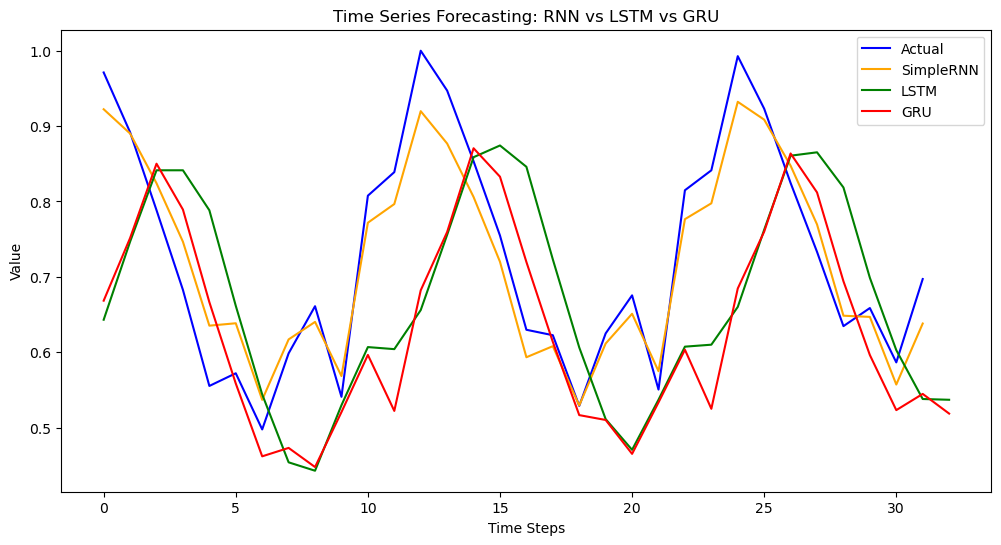

In [52]:
# Compare the performance of RNN, LSTM, and GRU.
# plotting in graph all three models RMSE,MAE,MAPE
plt.figure(figsize=(12,6))

plt.plot(Y_test, label='Actual', color='blue')
plt.plot(Y_pred, label='SimpleRNN', color='orange')
plt.plot(Y_pred1, label='LSTM', color='green')
plt.plot(Y_pred2, label='GRU', color='red')

plt.title("Time Series Forecasting: RNN vs LSTM vs GRU")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [53]:
# # comparing all the three models Simple RNN is not suitable because it has more error
# comparing to LSTM and GRU , GRU is best because it is faster , low rmse and mae.
# GRU model suits the best for the given data set.

In [54]:
# 5. Prediction and Visualization
#	Forecast milk production for the next 12 months.
#	Visualize the predicted trend with uncertainty or confidence intervals if possible.

In [64]:
# 5. Prediction and Visualization
#	Forecast milk production for the next 12 months.
import numpy as np
import pandas as pd
window_size= 12
# Take the last 'window_size' points from your scaled data
last_sequence = scaled_data[-window_size:]  # shape: (window_size, 1)

# Forcasting for next 12 months
n_future = 12  # forcasting for next 12 months
forecast_scaled = []
current_sequence= last_sequence.copy()

for i in range(n_future):
    pred = model2.predict(current_sequence.reshape(1,window_size,1))
    forecast_scaled.append(pred[0,0])
    current_sequence= np.append(current_sequence[1:],[[pred[0,0]]],axis=0)
    
# converting into array 
forecast_scaled = np.array(forecast_scaled).reshape(-1,1)    

# converting back to original milk productions
forecast=  scaler.inverse_transform(forecast_scaled)

# creating dates for future months
last_date= df.index[-1]  # last date in dataset
future_dates= pd.date_range(start=last_date,periods=13,freq='M')[1:]
print(future_dates)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
DatetimeIndex(['1976-01-31', '1976-02-29', '1976-03-31', '1976-04-30',
               '1976-05-31', '1976-06-30', '1976-07-31', '1976-08-31',
               '1976-09-30', '1976-10-31', '1976-11-30', '1976-12-31'],
              dtype='datetime64[ns]', freq='ME')


C:\Users\andeb\AppData\Local\Temp\ipykernel_13168\100587128.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates= pd.date_range(start=last_date,periods=13,freq='M')[1:]


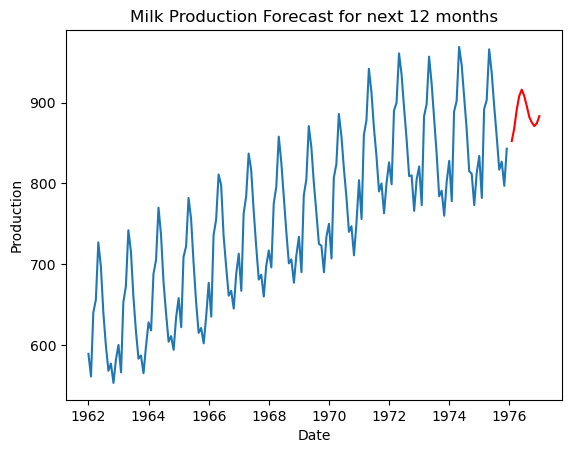

In [65]:
# plot the actual and forecasting values
import matplotlib.pyplot as plt
plt.plot(df.index,df["Production"],label ="Actual")
plt.plot(future_dates,forecast,label ="Forecast" ,color='red')
plt.title("Milk Production Forecast for next 12 months")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

In [66]:
print(forecast)

[[852.5196 ]
 [867.698  ]
 [891.3596 ]
 [908.1992 ]
 [916.09125]
 [908.41736]
 [895.80786]
 [882.17883]
 [875.4863 ]
 [870.9308 ]
 [874.443  ]
 [883.2722 ]]


In [68]:
# forecast values in the dataframe for next 12 months
forecast_df= pd.DataFrame({
    "Date":future_dates,
    "Predicted Milk Production": forecast.flatten()
})
print(forecast_df)

         Date  Predicted Milk Production
0  1976-01-31                 852.519592
1  1976-02-29                 867.697998
2  1976-03-31                 891.359619
3  1976-04-30                 908.199219
4  1976-05-31                 916.091248
5  1976-06-30                 908.417358
6  1976-07-31                 895.807861
7  1976-08-31                 882.178833
8  1976-09-30                 875.486328
9  1976-10-31                 870.930786
10 1976-11-30                 874.442993
11 1976-12-31                 883.272217


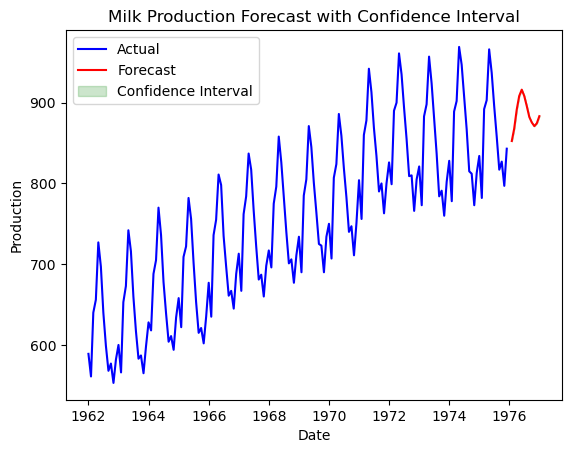

In [74]:
#	Visualize the predicted trend with uncertainty or confidence intervals if possible.
import numpy as np
import matplotlib.pyplot as plt
forecast_values = forecast.flatten()

# Simple estimated uncertainty using training RMSE
rmse = 0.13  #  RMSE for GRU model is 0.13
upper_bound = forecast_values + rmse
lower_bound = forecast_values - rmse

# Plot actual + forecast + confidence interval
plt.plot(df.index,df['Production'],label='Actual',color='blue')
plt.plot(future_dates,forecast_values,label='Forecast',color='red')

# confidence interval
plt.fill_between(future_dates,lower_bound,upper_bound,color='green',alpha=0.2,label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Production')
plt.title('Milk Production Forecast with Confidence Interval')
plt.legend()
plt.show()

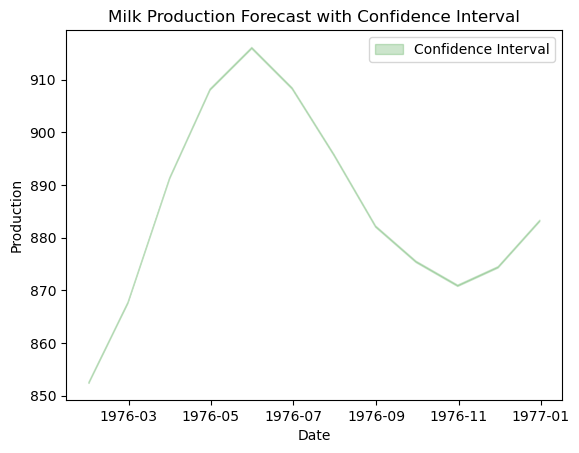

In [75]:
# confidence interval
plt.fill_between(future_dates,lower_bound,upper_bound,color='green',alpha=0.2,label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Production')
plt.title('Milk Production Forecast with Confidence Interval')
plt.legend()
plt.show()

In [ ]:
# 6. Business Insights
# Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

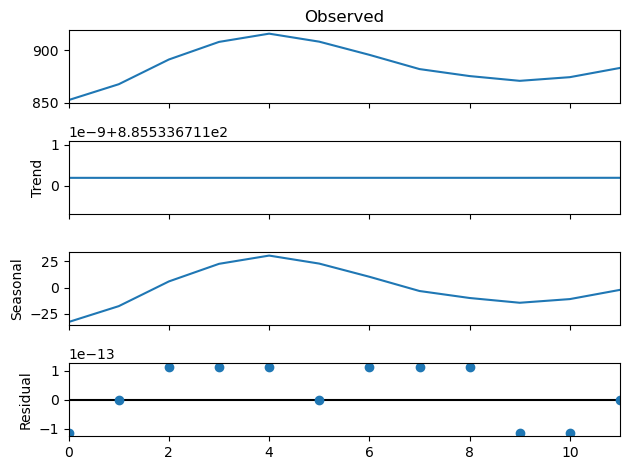

In [77]:
# Trend ,seasonality on forecast values
from statsmodels.tsa.seasonal import STL
ts1 = forecast_values
stl = STL(ts1,period=12)
result = stl.fit()
result.plot()
plt.show()

In [ ]:
# Observed: The raw data shows a clear peak midway and a dip toward the end, which suggests some cyclical behavior
# Trend : The nearly flat line indicates there is no strong upward or downward movement over the long term. 
#         So, whatever changes we see are not driven by a persistent trend.
# Seasonality: It mirrors the observed data closely, meaning seasonality is the dominant factor shaping this series
# Residual: Since the residuals hover close to zero, the decomposition model has captured most of the variation
# Overall review :
# Seasonal Patterns
#   Dairy sales often show seasonal changes.
#   In march,april and may production is high 
#   Higher demand during summer for products like ice cream, curd, and flavored milk.
#   Lower demand in certain months(january,febuary)
#   Understanding seasonality helps the dairy plan production cycles.
#   There is less need during january and feburary compared to other months so better to store for next three months where more milk is needed.
#   Increase temperory workman power during seasonality,and can reduce accordingly.
#   Have to plan budget for january and feburary months for higher production.